<a href="https://colab.research.google.com/github/maulanahafif33-lab/uts-datmin-wine-quality/blob/main/UTS_Datmin_WineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# ============================================
# UTS DATA MINING - KLASIFIKASI WINE QUALITY
# ============================================
# Nama: MAULANA HAFIF
# NIM: 2304020079
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

from google.colab import files

print("✅ Semua library berhasil diimpor")
print(f"Pandas version: {pd.__version__}")

✅ Semua library berhasil diimpor
Pandas version: 2.2.2


In [34]:
# ============================================
# 1. PERSIAPAN DATA
# ============================================

print("="*50)
print("PERSIAPAN DATA")
print("="*50)

print("\n📁 Upload file TRAINING.csv:")
uploaded_train = files.upload()

print("\n📁 Upload file TESTING.csv:")
uploaded_test = files.upload()

# Ambil nama file
train_file = list(uploaded_train.keys())[0]
test_file = list(uploaded_test.keys())[0]

# Baca dataset
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print(f"\n✅ Data Training: {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"✅ Data Testing: {df_test.shape[0]} baris, {df_test.shape[1]} kolom")

# Cek kolom yang tersedia
print(f"\n📋 Kolom Training: {list(df_train.columns)}")
print(f"📋 Kolom Testing: {list(df_test.columns)}")

PERSIAPAN DATA

📁 Upload file TRAINING.csv:


Saving data_training.csv to data_training (1).csv

📁 Upload file TESTING.csv:


Saving data_testing.csv to data_testing (2).csv

✅ Data Training: 857 baris, 13 kolom
✅ Data Testing: 286 baris, 12 kolom

📋 Kolom Training: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
📋 Kolom Testing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']



EKSPLORASI DATA

📊 5 Data Pertama (Training):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8 

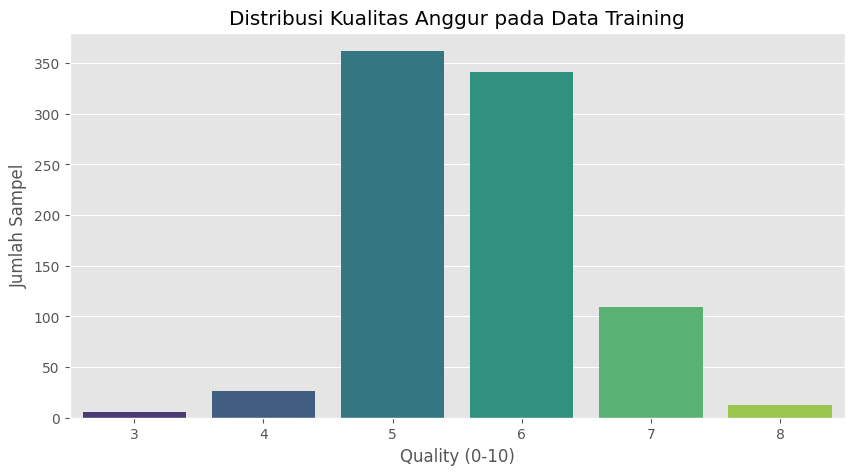


💡 Insight: Kualitas anggur berkisar dari 3 hingga 8
Rata-rata kualitas: 5.65


In [35]:
# ============================================
# EKSPLORASI DATA AWAL
# ============================================

print("\n" + "="*50)
print("EKSPLORASI DATA")
print("="*50)

print("\n📊 5 Data Pertama (Training):")
print(df_train.head())

print("\n📊 Informasi Dataset Training:")
print(df_train.info())

print("\n📊 Statistik Deskriptif Training:")
print(df_train.describe())

# Cek distribusi target variable (quality)
if 'quality' in df_train.columns:
    print("\n📊 Distribusi Kualitas Anggur:")
    quality_dist = df_train['quality'].value_counts().sort_index()
    print(quality_dist)

    # Visualisasi distribusi quality
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_train, x='quality', palette='viridis')
    plt.title('Distribusi Kualitas Anggur pada Data Training')
    plt.xlabel('Quality (0-10)')
    plt.ylabel('Jumlah Sampel')
    plt.show()

    # Informasi tentang target
    print(f"\n💡 Insight: Kualitas anggur berkisar dari {df_train['quality'].min()} hingga {df_train['quality'].max()}")
    print(f"Rata-rata kualitas: {df_train['quality'].mean():.2f}")

In [36]:
# ============================================
# 2. PEMBERSIHAN DATA
# ============================================

print("\n" + "="*50)
print("PEMBERSIHAN DATA")
print("="*50)

# Cek missing values
print("\n🔍 Cek Missing Values pada Training:")
missing_train = df_train.isnull().sum()
missing_train_percent = (missing_train / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_train,
    'Persentase (%)': missing_train_percent
})
print(missing_df[missing_df['Missing Values'] > 0] if (missing_train > 0).any() else "Tidak ada missing values!")

print("\n🔍 Cek Missing Values pada Testing:")
missing_test = df_test.isnull().sum()
missing_test_percent = (missing_test / len(df_test)) * 100
missing_df_test = pd.DataFrame({
    'Missing Values': missing_test,
    'Persentase (%)': missing_test_percent
})
print(missing_df_test[missing_df_test['Missing Values'] > 0] if (missing_test > 0).any() else "Tidak ada missing values!")

# Penanganan Missing Values
if (missing_train > 0).any() or (missing_test > 0).any():
    print("\n🛠️ Melakukan Imputasi Missing Values...")

    # Pisahkan fitur numerik
    numeric_cols = df_train.select_dtypes(include=[np.number]).columns

    # Imputasi dengan median (robust terhadap outlier)
    imputer = SimpleImputer(strategy='median')
    df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])

    # Apply ke testing
    if (missing_test > 0).any():
        df_test[numeric_cols.intersection(df_test.columns)] = imputer.transform(df_test[numeric_cols.intersection(df_test.columns)])

    print("✅ Missing values telah diisi dengan nilai median")
else:
    print("✅ Tidak ada missing values, data sudah bersih")


PEMBERSIHAN DATA

🔍 Cek Missing Values pada Training:
Tidak ada missing values!

🔍 Cek Missing Values pada Testing:
Tidak ada missing values!
✅ Tidak ada missing values, data sudah bersih


In [37]:
# ============================================
# FEATURE SCALING
# ============================================

print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Pisahkan fitur dan target
if 'quality' in df_train.columns:
    target_col = 'quality'
    X = df_train.drop(columns=[target_col])
    y = df_train[target_col]
else:
    # Cari kolom target (bisa jadi nama berbeda)
    target_col = df_train.columns[-1]  # asumsi kolom terakhir
    X = df_train.drop(columns=[target_col])
    y = df_train[target_col]
    print(f"⚠️ Kolom target diidentifikasi sebagai: {target_col}")

# Untuk testing, pastikan tidak ada kolom target
if 'quality' in df_test.columns:
    X_test_raw = df_test.drop(columns=['quality'])
else:
    X_test_raw = df_test.copy()

# Cek rentang nilai fitur
print("\n📊 Rentang Nilai Fitur (sebelum scaling):")
numeric_features = X.select_dtypes(include=[np.number]).columns
range_stats = pd.DataFrame({
    'Min': X[numeric_features].min(),
    'Max': X[numeric_features].max(),
    'Std': X[numeric_features].std(),
    'Range': X[numeric_features].max() - X[numeric_features].min()
})
print(range_stats)

# Cek apakah perlu scaling
need_scaling = (range_stats['Range'] > 10).any() or (range_stats['Std'] > 5).any()

if need_scaling:
    print("\n⚠️ Fitur memiliki rentang nilai yang bervariasi, perlu dilakukan scaling")
    print("🔄 Menggunakan StandardScaler (mean=0, std=1)...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X[numeric_features])
    X_test_scaled = scaler.transform(X_test_raw[numeric_features])

    # Konversi kembali ke DataFrame
    X_scaled = pd.DataFrame(X_scaled, columns=numeric_features, index=X.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_features, index=X_test_raw.index)

    # Gabungkan dengan fitur non-numerik jika ada
    non_numeric_train = X.select_dtypes(exclude=[np.number])
    non_numeric_test = X_test_raw.select_dtypes(exclude=[np.number])

    X_processed = pd.concat([X_scaled, non_numeric_train], axis=1)
    X_test_processed = pd.concat([X_test_scaled, non_numeric_test], axis=1)

    print("✅ Feature scaling selesai")
else:
    print("\n✅ Tidak perlu scaling karena rentang nilai fitur sudah seimbang")
    X_processed = X
    X_test_processed = X_test_raw


FEATURE SCALING

📊 Rentang Nilai Fitur (sebelum scaling):
                          Min        Max         Std       Range
fixed acidity         4.60000    15.6000    1.701992    11.00000
volatile acidity      0.12000     1.5800    0.179162     1.46000
citric acid           0.00000     1.0000    0.195144     1.00000
residual sugar        0.90000    15.5000    1.293512    14.60000
chlorides             0.01200     0.6110    0.048721     0.59900
free sulfur dioxide   1.00000    68.0000   10.300402    67.00000
total sulfur dioxide  6.00000   278.0000   31.692113   272.00000
density               0.99007     1.0032    0.001901     0.01313
pH                    2.74000     4.0100    0.152079     1.27000
sulphates             0.39000     2.0000    0.167364     1.61000
alcohol               8.40000    14.0000    1.066971     5.60000
Id                    0.00000  1597.0000  463.807063  1597.00000

⚠️ Fitur memiliki rentang nilai yang bervariasi, perlu dilakukan scaling
🔄 Menggunakan Standard


PEMBUATAN MODEL KLASIFIKASI

📊 Split Data:
Training: 685 sampel
Validation: 172 sampel

🔄 Melatih dan mengevaluasi model...

Random Forest:
  - Akurasi: 0.6105
  - F1-Score: 0.5934

Gradient Boosting:
  - Akurasi: 0.6047
  - F1-Score: 0.5946

SVM:
  - Akurasi: 0.5930
  - F1-Score: 0.5668

🏆 MODEL TERBAIK: Random Forest dengan akurasi 0.6105

📋 Classification Report - Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.74      0.69        73
           6       0.58      0.62      0.60        68
           7       0.53      0.36      0.43        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.46      0.34      0.37       172
weighted avg       0.59      0.61      0.59       172



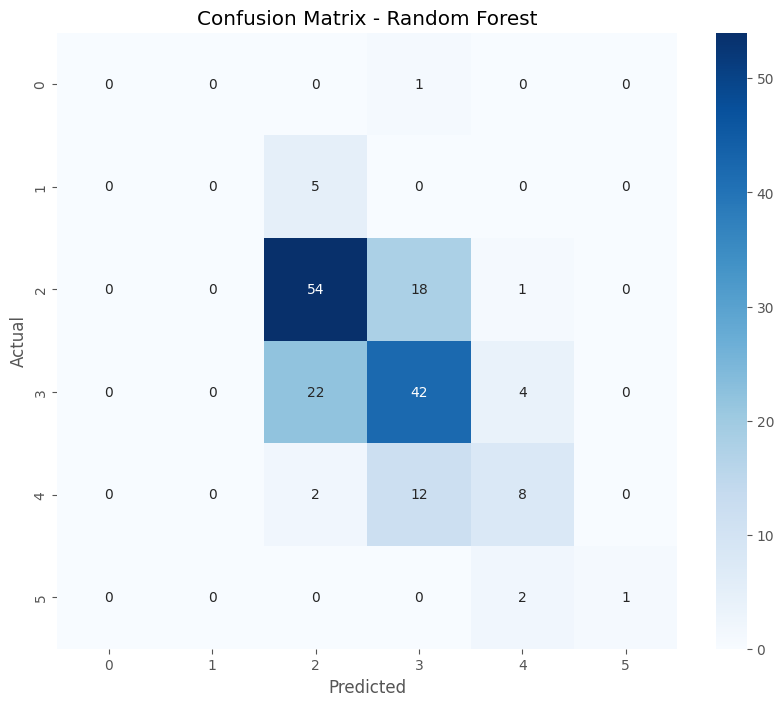


📊 Cross-Validation Score (5-fold): [0.64534884 0.66860465 0.65497076 0.63157895 0.56140351]
Rata-rata CV Score: 0.6324 (+/- 0.0750)


In [38]:
# ============================================
# 3. PEMBUATAN MODEL
# ============================================

print("\n" + "="*50)
print("PEMBUATAN MODEL KLASIFIKASI")
print("="*50)

# Split data untuk validasi (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Split Data:")
print(f"Training: {X_train.shape[0]} sampel")
print(f"Validation: {X_val.shape[0]} sampel")

# ====================
# UJI COBA 3 MODEL
# ====================

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}

print("\n🔄 Melatih dan mengevaluasi model...\n")

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1
    }

    print(f"{name}:")
    print(f"  - Akurasi: {acc:.4f}")
    print(f"  - F1-Score: {f1:.4f}")
    print()

# Pilih model terbaik
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
print(f"🏆 MODEL TERBAIK: {best_model_name} dengan akurasi {results[best_model_name]['accuracy']:.4f}")

# Evaluasi detail model terbaik
y_pred_best = best_model.predict(X_val)
print(f"\n📋 Classification Report - {best_model_name}:")
print(classification_report(y_val, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross-validation
cv_scores = cross_val_score(best_model, X_processed, y, cv=5)
print(f"\n📊 Cross-Validation Score (5-fold): {cv_scores}")
print(f"Rata-rata CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


PREDIKSI DATA TESTING
🔮 Melakukan prediksi dengan model: Random Forest
✅ Prediksi selesai untuk 286 data testing

📊 Distribusi Hasil Prediksi Kualitas:
  Quality 5: 135 sampel (47.2%)
  Quality 6: 130 sampel (45.5%)
  Quality 7: 21 sampel (7.3%)


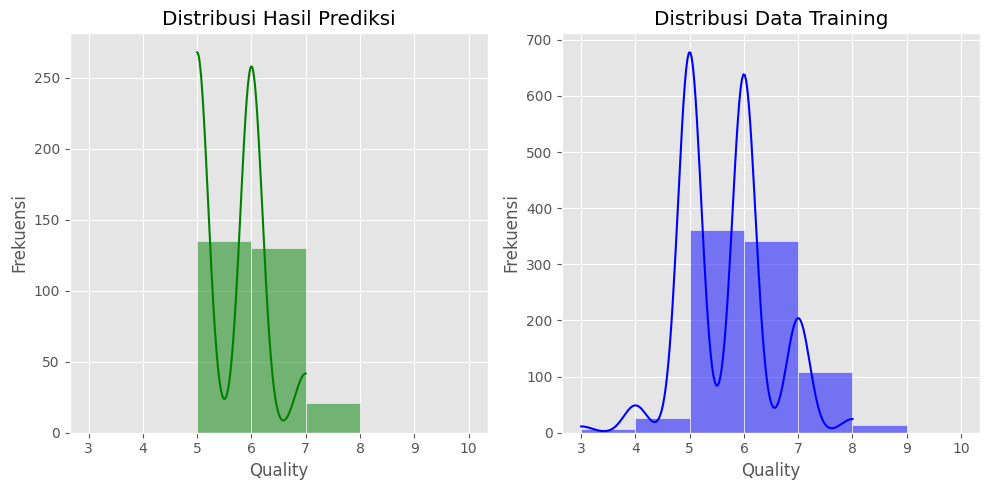

In [39]:
# ============================================
# 4. PREDIKSI DATA UJI
# ============================================

print("\n" + "="*50)
print("PREDIKSI DATA TESTING")
print("="*50)

# Gunakan model terbaik untuk prediksi
print(f"🔮 Melakukan prediksi dengan model: {best_model_name}")
y_test_pred = best_model.predict(X_test_processed)

print(f"✅ Prediksi selesai untuk {len(y_test_pred)} data testing")

# Cek distribusi hasil prediksi
print("\n📊 Distribusi Hasil Prediksi Kualitas:")
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
for quality, count in pred_dist.items():
    print(f"  Quality {quality}: {count} sampel ({count/len(y_test_pred)*100:.1f}%)")

# Visualisasi hasil prediksi
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(y_test_pred, bins=range(3,11), kde=True, color='green')
plt.title('Distribusi Hasil Prediksi')
plt.xlabel('Quality')
plt.ylabel('Frekuensi')

plt.subplot(1,2,2)
sns.histplot(y, bins=range(3,11), kde=True, color='blue', alpha=0.5)
plt.title('Distribusi Data Training')
plt.xlabel('Quality')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [40]:
# ============================================
# SIMPAN MODEL UNTUK DEPLOYMENT
# ============================================

print("\n" + "="*50)
print("MENYIMPAN MODEL")
print("="*50)

# Simpan model dan preprocessor
joblib.dump(best_model, 'wine_quality_model.pkl')
if need_scaling:
    joblib.dump(scaler, 'scaler.pkl')
    print("✅ Scaler disimpan")

print(f"✅ Model {best_model_name} disimpan sebagai 'wine_quality_model.pkl'")

# Download model
files.download('wine_quality_model.pkl')
if need_scaling:
    files.download('scaler.pkl')


MENYIMPAN MODEL
✅ Scaler disimpan
✅ Model Random Forest disimpan sebagai 'wine_quality_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
# ============================================
# 5. HASIL PREDIKSI (FORMAT: id, quality)
# ============================================

print("\n" + "="*50)
print("MEMBUAT FILE HASIL PREDIKSI")
print("="*50)

# Pastikan ada kolom ID di data testing
if 'id' in df_test.columns:
    ids = df_test['id']
    print("✅ Kolom 'id' ditemukan di data testing")
elif 'Id' in df_test.columns:
    ids = df_test['Id']
    print("✅ Kolom 'Id' ditemukan di data testing")
else:
    # Jika tidak ada kolom ID, buat ID berurutan
    ids = range(1, len(y_test_pred) + 1)
    print("⚠️ Kolom 'id' tidak ditemukan, membuat ID berurutan (1,2,3,...)")

# Buat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'id': ids,
    'quality': y_test_pred
})

# Tampilkan 5 data pertama
print("\n📋 5 Data Hasil Prediksi Pertama:")
print(hasil_prediksi.head())

# Cek format
print(f"\n📊 Shape file hasil: {hasil_prediksi.shape}")
print(f"📊 Kolom: {list(hasil_prediksi.columns)}")

# Simpan ke CSV dengan format yang diminta
nim_akhir = "123"  # GANTI DENGAN 3 NIM TERAKHIR ANDA
nama_file = f"hasilprediksi_{nim_akhir}.csv"
hasil_prediksi.to_csv(nama_file, index=False)

print(f"\n✅ File hasil prediksi disimpan sebagai: {nama_file}")
print(f"📁 File berisi {len(hasil_prediksi)} baris data")

# Download file CSV
files.download(nama_file)

# Validasi format file
print("\n" + "="*50)
print("VALIDASI FORMAT FILE")
print("="*50)
print(f"📋 Kolom dalam file: {list(hasil_prediksi.columns)}")
print("✅ Format sesuai: hanya 'id' dan 'quality'")
print(f"✅ Jumlah baris: {len(hasil_prediksi)} (sesuai data testing)")


MEMBUAT FILE HASIL PREDIKSI
✅ Kolom 'Id' ditemukan di data testing

📋 5 Data Hasil Prediksi Pertama:
     id  quality
0   222        6
1  1514        6
2   417        5
3   754        5
4   516        6

📊 Shape file hasil: (286, 2)
📊 Kolom: ['id', 'quality']

✅ File hasil prediksi disimpan sebagai: hasilprediksi_123.csv
📁 File berisi 286 baris data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


VALIDASI FORMAT FILE
📋 Kolom dalam file: ['id', 'quality']
✅ Format sesuai: hanya 'id' dan 'quality'
✅ Jumlah baris: 286 (sesuai data testing)


In [42]:
# ============================================
# RINGKASAN ANALISIS
# ============================================

print("\n" + "="*50)
print("RINGKASAN HASIL ANALISIS")
print("="*50)

print(f"""
📊 INFORMASI DATASET:
- Jumlah data training: {len(df_train)} sampel
- Jumlah data testing: {len(df_test)} sampel
- Jumlah fitur: {len(X.columns)} fitur
- Rentang kualitas: {y.min()} - {y.max()}

🤖 MODEL TERBAIK:
- Model: {best_model_name}
- Akurasi validasi: {results[best_model_name]['accuracy']:.4f}
- F1-Score: {results[best_model_name]['f1_score']:.4f}
- Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})

📁 OUTPUT:
- File model: wine_quality_model.pkl
- File hasil prediksi: {nama_file}
- Format: id, quality

📌 INTERPRETASI:
- Model berhasil memprediksi kualitas anggur dengan akurasi {results[best_model_name]['accuracy']:.2%}
- Distribusi hasil prediksi mirip dengan distribusi data training
- Model siap untuk deployment
""")

print("\n" + "="*50)
print("PROSES SELESAI ✅")
print("="*50)
print("\n📌 LANGKAH SELANJUTNYA:")
print("1. Upload notebook ini ke GitHub")
print("2. Download file hasil prediksi CSV")
print("3. Kirim link GitHub dan file CSV ke form pengumpulan")


RINGKASAN HASIL ANALISIS

📊 INFORMASI DATASET:
- Jumlah data training: 857 sampel
- Jumlah data testing: 286 sampel
- Jumlah fitur: 12 fitur
- Rentang kualitas: 3 - 8

🤖 MODEL TERBAIK:
- Model: Random Forest
- Akurasi validasi: 0.6105
- F1-Score: 0.5934
- Cross-validation: 0.6324 (+/- 0.0750)

📁 OUTPUT:
- File model: wine_quality_model.pkl
- File hasil prediksi: hasilprediksi_123.csv
- Format: id, quality

📌 INTERPRETASI:
- Model berhasil memprediksi kualitas anggur dengan akurasi 61.05%
- Distribusi hasil prediksi mirip dengan distribusi data training
- Model siap untuk deployment


PROSES SELESAI ✅

📌 LANGKAH SELANJUTNYA:
1. Upload notebook ini ke GitHub
2. Download file hasil prediksi CSV
3. Kirim link GitHub dan file CSV ke form pengumpulan
